# Marigold horizontal leafs detector by using the sacred framework 

## 1. Imports and configuration

In [9]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "science_jubilee").is_dir():
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not locate the science_jubilee repository root")

SRC_ROOT = REPO_ROOT / "src"
for path in (SRC_ROOT, REPO_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)


from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.filter_scene import run_filter_scene
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.target_horizontals import run_estimate_horizontal_targets
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.reconstruction import run_reconstruction
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.extract_leafs import run_extract_leaf_clusters 

import imageio

DETECTOR_ROOT = SRC_ROOT / "science_jubilee/Vision/Marigold_Horizontal_leafs"
IMAGE_DIR = DETECTOR_ROOT / "input"
OUTPUT_DIR = DETECTOR_ROOT / "output/latest"
CONFIG_PATH = DETECTOR_ROOT / "config.yaml"
IMAGE_PATH = IMAGE_DIR / "latest.jpg"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STEPS =10
RUN_RECONSTRUCTION = False
TARGET_AUTO = False

def show(image, title=""):
    image_array = np.asarray(image)
    display_image = image_array if image_array.ndim == 3 else image_array
    plt.figure(figsize=(10, 7))
    plt.imshow(display_image, cmap="gray" if image_array.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()
    
hardware=True


## 2. Capture the latest image (optional hardware step)

In [10]:
import time

if hardware:
    env = ".env.hardware"
else:
    env = ".env.mock"
    
session = MachineSession.from_env(env)
cam = session.camera
    
# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
if hardware == False:
    cam._image =  imageio.imread("input/test.png")
else:
    
    cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

image = cam.get_image()
image_out=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.imwrite(str(IMAGE_PATH), image_out)
print(f"Saved {IMAGE_PATH}")

Saved c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\input\latest.jpg


## 3. Load and inspect the image

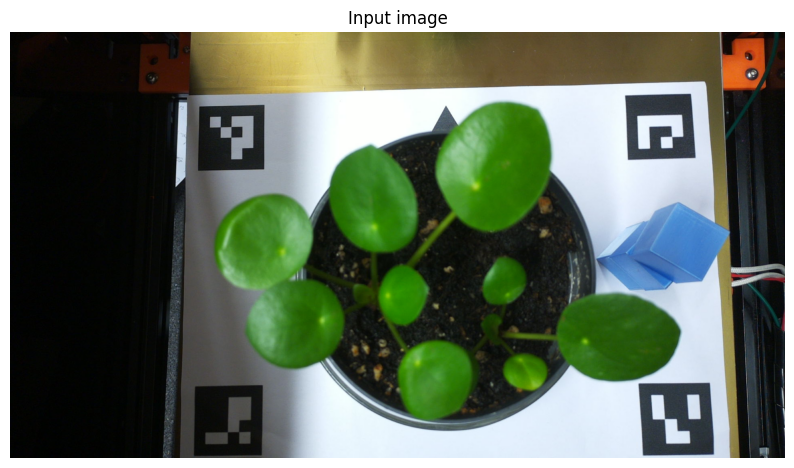

In [11]:
image2 = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(f"Unable to read {IMAGE_PATH}")
show(image, "Input image")


## 4. Segment the tray and plant

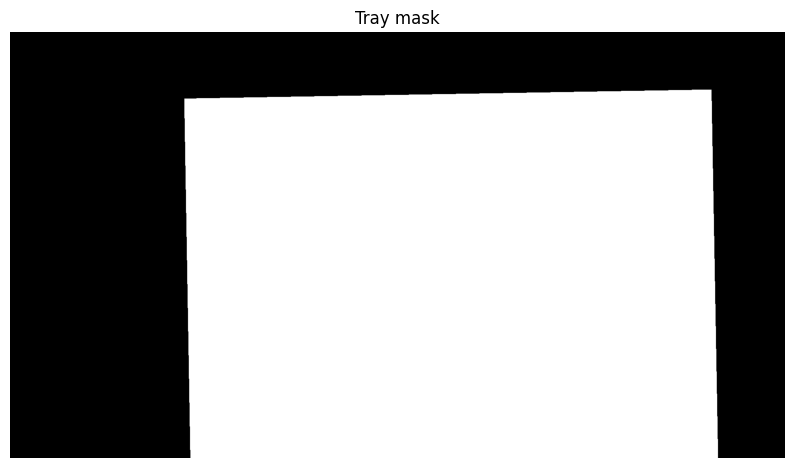

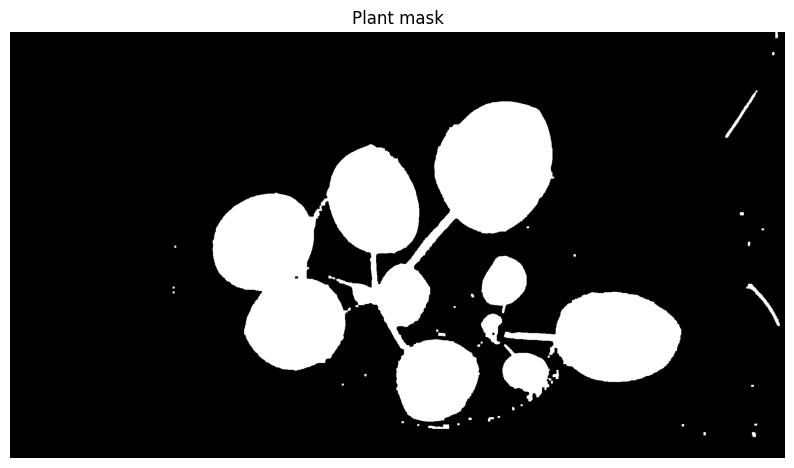

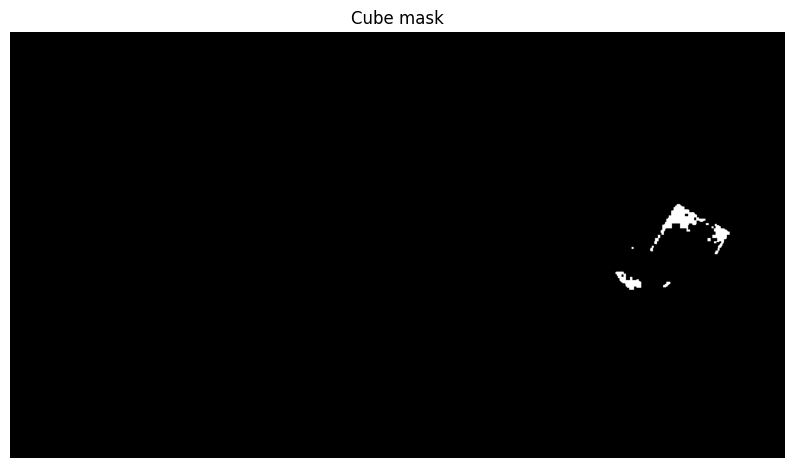

In [12]:
filtered = run_filter_scene(image=image)
show(filtered["tray_mask"], "Tray mask")
show(filtered["plant_mask"], "Plant mask")
show(filtered["cube_mask"], "Cube mask")

## 5. Estimate depth and surface normals

## With Marigold

[+] Using device: cuda
[+] Loading Marigold depth and normal models...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Running normal estimation...


Marigold predictions...:   0%|          | 0/1 [00:00<?, ?it/s]

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Depth saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_depth.npy
[+] Normals saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_normals.npy
Depth shape: (1056, 1920)
Normals shape: (1056, 1920, 3)


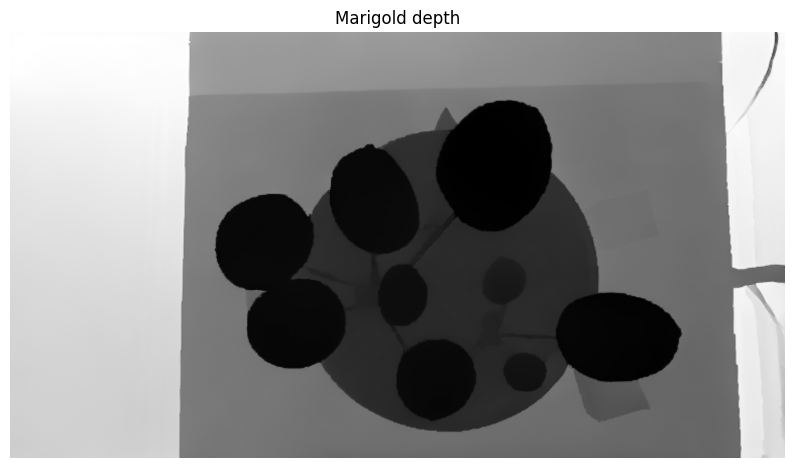

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


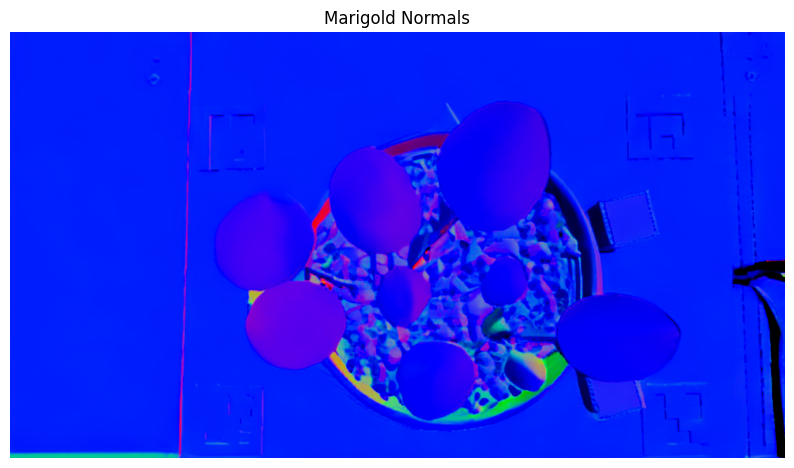

Range des profondeurs : min = 0.000, max = 1.000
Range des normales    : min = -1.000, max = 1.000


In [5]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_marigold import run_infer_depths_and_normals

inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    steps=1000,
    image_name=IMAGE_PATH.name,
)
depth_map = inference["depth"].squeeze()
normals = inference["normals"]

print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "Marigold depth")
show(normals,"Marigold Normals" )


# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

In [6]:

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

Range des profondeurs : min = 0.000, max = 0.998
Range des normales    : min = -1.000, max = 1.000


## With MoGe v3



Depth shape: (1056, 1920)
Normals shape: (1056, 1920, 3)


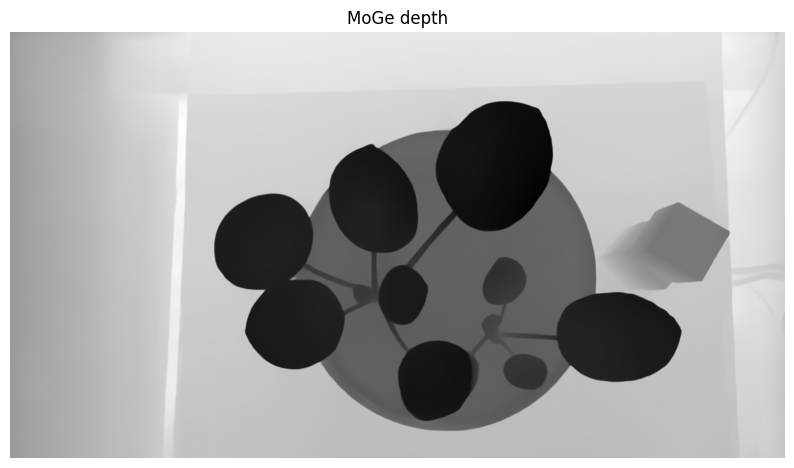

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.97097933].


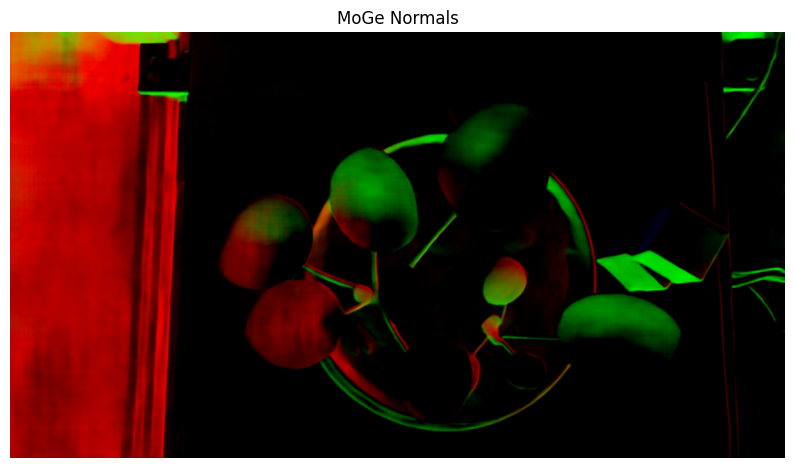

Range des profondeurs : min = 0.224, max = 0.692
Range des normales    : min = -1.000, max = 0.971


In [13]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_MoGe import run_infer_depths_and_normals
inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
    resolution_level=10
)
depth_map = inference["depth"]
normals = inference["normals"]
print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "MoGe depth")
show(normals,"MoGe Normals" )

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

In [6]:
import open3d as o3d
points= inference["3d_points"]
raw_pcd = o3d.geometry.PointCloud()
raw_points = np.asarray(points).reshape(-1, 3)
raw_points = raw_points[np.isfinite(raw_points).all(axis=1)]
raw_pcd.points = o3d.utility.Vector3dVector(raw_points)



raw_pcd_path = "./output_3d / raw_pcd.ply"
o3d.io.write_point_cloud(str(raw_pcd_path), raw_pcd)
print(f"Saved {len(raw_points)} points to {raw_pcd_path}")

[Open3D WARNING] Write PLY failed: unable to open file: .\output_3d \ raw_pcd.ply
Saved 2027520 points to ./output_3d / raw_pcd.ply


## 6. Detect horizontal leaf targets


[DEBUG] START TARGET ESTIMATION PIPELINE
[+] Tray depth values: 828156 pixels, min=0.27, max=0.69
[+] Cube depth values: 41939 pixels, min=0.42, max=0.56
[1. Depth Scaling] Min: 189.64 mm | Max: 320.00 mm
[4. Clustering] 1er DBSCAN (Spatial 3D) sur 86683 points (eps=1.8mm)...
    -> Blobs spatiaux initiaux  : 9
    -> Blobs scindés par normal : 0
    -> Blobs cibles finaux      : 7

[+] Final valid targets detected: 7

Targets detected: 7


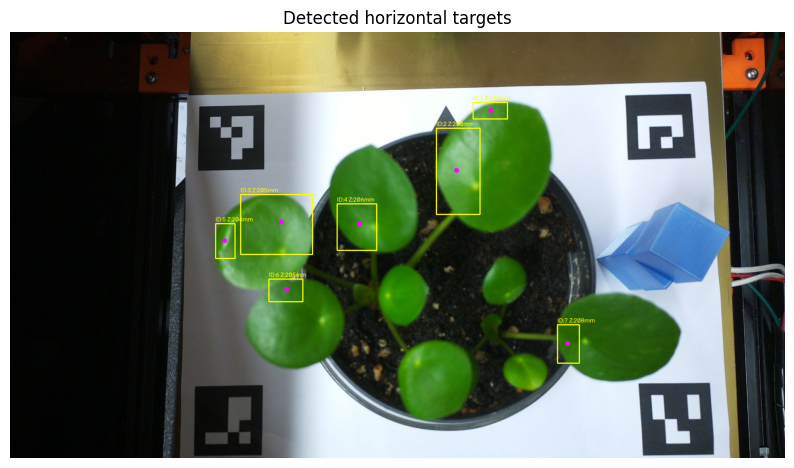

In [15]:
import yaml
targets_result = run_estimate_horizontal_targets(
    image=image,
    depth_map=depth_map,
    normals=normals,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
    tray_z_mm=Z_DEPART,
    normal_threshold=0.94,
    min_area_px=2000,
    max_area_px=150000,
    cluster_eps_mm=1.8,
    cluster_eps_normal=0.1,
    camera=cam,
    plant_height=None,
    scale_cube=75,
)
targets = targets_result["targets"]
overlay = targets_result["overlay"]
depth_mm=targets_result["depth_mm"]
print(f"Targets detected: {len(targets)}")
show(overlay, "Detected horizontal targets")

## 7. Select a target

In [29]:
if not targets:
    raise RuntimeError("No horizontal targets detected; inspect the masks or rerun inference.")
if TARGET_AUTO:
    target = max(targets, key=lambda item: -item["xyz_mm"][2])
else:
    for index, candidate in enumerate(targets):
        print(index, candidate)
        print("Select a target among the above list")

0 {'id': 1, 'pixel': [1442, 180], 'area_px': 11955, 'bbox': [1366, 121, 160, 123], 'normal_confidence': -0.9966967701911926, 'depth_std_mm': 0.9116944074630737, 'xyz_mm': [56.313655853271484, -42.36337661743164, 173.3213348388672], 'normal': [-0.017427053302526474, 0.07932181656360626, -0.9966967701911926]}
Select a target among the above list
1 {'id': 2, 'pixel': [1153, 187], 'area_px': 4436, 'bbox': [1117, 127, 74, 113], 'normal_confidence': -0.9820619225502014, 'depth_std_mm': 0.5407626032829285, 'xyz_mm': [23.127643585205078, -42.91796112060547, 178.05572509765625], 'normal': [-0.08359350264072418, 0.16901631653308868, -0.9820619225502014]}
Select a target among the above list
2 {'id': 3, 'pixel': [877, 346], 'area_px': 3629, 'bbox': [846, 298, 76, 86], 'normal_confidence': -0.977852463722229, 'depth_std_mm': 0.7047315239906311, 'xyz_mm': [-10.628652572631836, -24.652469635009766, 183.80923461914062], 'normal': [-0.10284755378961563, 0.18228265643119812, -0.977852463722229]}
Select

In [25]:
target = targets[3]  #your target choice
print("Selected target:", target)
print(target['xyz_mm'])


Selected target: {'id': 4, 'pixel': [743, 491], 'area_px': 6720, 'bbox': [698, 443, 90, 97], 'normal_confidence': -0.9991392493247986, 'depth_std_mm': 0.5330132842063904, 'xyz_mm': [-27.559717178344727, -6.681613922119141, 184.89645385742188], 'normal': [-0.005529685877263546, -0.04111253470182419, -0.9991392493247986]}
[-27.559717178344727, -6.681613922119141, 184.89645385742188]


## 8. Move into the target

In [ ]:
supplementary_offset_xyz = [
        5,
        25.0,
        -9,
    ]
# On se déplace vers le target en gardant la même hauteur
if hardware:    
    nav= session.free_navigator
    nav.move_to(
            z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] +supplementary_offset_xyz[2] +30 , speed=1000.0, wait=True
        )
    nav.move_to(
        x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
        y=Y_DEPART - target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
        speed=3000.0,
        wait=True,
    )
    nav.move_to(
        z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] +supplementary_offset_xyz[2], speed=1000.0, wait=True
    )

In [ ]:
for target in targets[0:]:
    supplementary_offset_xyz = [
        5,
        25.0,
       -9,
    ]
    # On se déplace vers le target en gardant la même hauteur
    if hardware:    
        nav= session.free_navigator
        nav.move_to(
                z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] +supplementary_offset_xyz[2] +30 , speed=1000.0, wait=True
            )
        nav.move_to(
            x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
            y=Y_DEPART - target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
            speed=3000.0,
            wait=True,
        )
        nav.move_to(
            z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] +supplementary_offset_xyz[2], speed=1000.0, wait=True
        )

## 9. Create Point cloud from depth

In [22]:
#only Point cloud reconstruction
results = run_reconstruction(
    image=image,
    depth_mm=depth_mm,
    camera=cam,
    meshing=False,  
    alpha=0.005,           # Paramètre de l'Alpha Shape (plus petit = plus fin/troué)
    decimate_ratio=0.5,    # Réduit le nombre de triangles de 50%
    output_dir="./output_3d",
    image_name="test_plant.jpg"
)

[3D] Génération du nuage de points en mémoire...
[3D] Nuage brut généré avec 2027520 points.
[3D] Filtrage statistique des valeurs aberrantes...
[+] Nuage de points sauvegardé : output_3d\test_plant_point_cloud.ply


In [11]:
import open3d as o3d
results = run_reconstruction(
    image=image,
    depth_mm=depth_mm,
    camera=cam,
    meshing=True,
    alpha=0.005,           # Paramètre de l'Alpha Shape (plus petit = plus fin/troué)
    decimate_ratio=0.5,    # Réduit le nombre de triangles de 50%
    output_dir="./output_3d",
    image_name="test_plant.jpg"
)

# 4. Extraction du maillage
mesh = results["mesh"]

# 5. Visualisation interactive avec Open3D
print("[Visualisation] Ouverture de la fenêtre Open3D... (Fermez la fenêtre pour rendre la main au script)")

# On recalcule les normales pour que la lumière s'affiche correctement sur le mesh
mesh.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [mesh],
    window_name="Reconstruction 3D - Maillage des feuilles",
    width=1280,
    height=720,
    mesh_show_wireframe=False,   
    mesh_show_back_face=True     
)

[3D] Génération du nuage de points en mémoire...
[3D] Nuage brut généré avec 2027520 points.
[3D] Filtrage statistique des valeurs aberrantes...
[+] Nuage de points sauvegardé : output_3d\test_plant_point_cloud.ply
Triangles generated : 6 144 590
 Quadratic decimation  keeping only 3 072 295 faces.
[+] Maillage sauvegardé : output_3d\test_plant_mesh.ply
[Visualisation] Ouverture de la fenêtre Open3D... (Fermez la fenêtre pour rendre la main au script)


## DEBUG ONLY: find best parameters for segentation and clustering of plants 

In [44]:
import cv2
import numpy as np
from skimage.segmentation import watershed
from skimage.filters import sobel
from sklearn.cluster import DBSCAN

tray_mask=filtered["tray_mask"]
plant_mask=filtered["plant_mask"]
cube_mask=filtered["cube_mask"]
config = {
    "camera": {
        "cx": 966.6098775996533,
        "cy": 533.9822650713481,
        "dist": [
            -0.01774652120816888,
            0.34775989653378375,
            -8.43022105306137e-05,
            0.0013051523863665852,
            -0.7666010432176091,
        ],
        "fx": 1453.20885729982,
        "fy": 1462.5327058475916,
    },
    "physical": {
        "tray_z_mm": 320.00,
        "plant_height_mm": 155.0,
        "tray_reference_mm": 320.00,
    },
    "filtering": {"min_area_px": 2000,
                  "max_area_px": 150000,
  "min_normal_z": 0.95,
  "cluster_eps_mm": 1.8,
  "cluster_eps_normal": 0.01
        }
}
intrinsics=config["camera"]
plant_height=160
scale_cube=None

In [45]:

def depth_to_camera_xyz(
    depth_map: np.ndarray, u: float, v: float, intrinsics: dict
) -> np.ndarray:
    # Thanks to the depth estimated  we can compute the real world cordinates using camera pinhole model with iis calibrated camera parameters
    h, w = depth_map.shape[:2]
    u0 = int(np.clip(round(u), 0, w - 1))
    v0 = int(np.clip(round(v), 0, h - 1))
    z_value = np.asarray(depth_map[v0, u0]).reshape(-1)[0]
    z = float(z_value)

    K = np.array(
        [
            [intrinsics["fx"], 0, intrinsics["cx"]],
            [0, intrinsics["fy"], intrinsics["cy"]],
            [0, 0, 1],
        ],
        dtype=np.float32,
    )
    # Improvement of the model by including the distortion parameters given py the opencv calibration

    dist_np = np.array(intrinsics["dist"], dtype=np.float32)
    point_2d = np.array([[[u, v]]], dtype=np.float32)

    undistorted_pt = cv2.undistortPoints(point_2d, K, dist_np)
    x_norm = undistorted_pt[0, 0, 0]
    y_norm = undistorted_pt[0, 0, 1]

    x = x_norm * z
    y = y_norm * z
    return np.array([x, y, z], dtype=np.float32)



[DEBUG] START TARGET ESTIMATION PIPELINE
[1. Depth Scaling] Min: 160.00 mm | Max: 320.41 mm


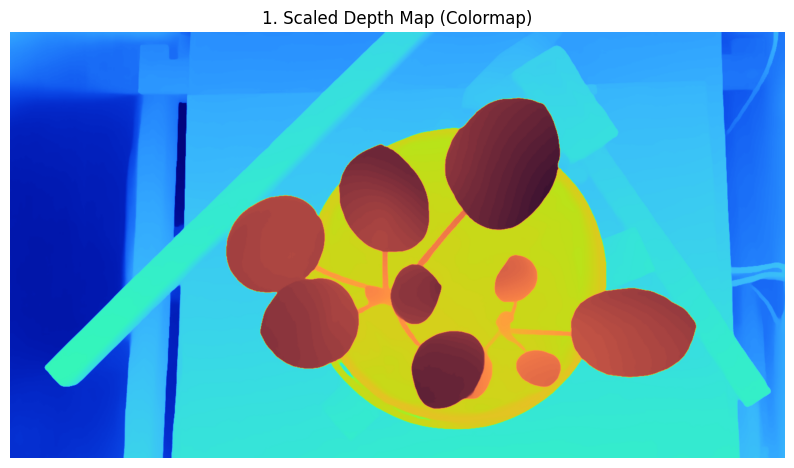

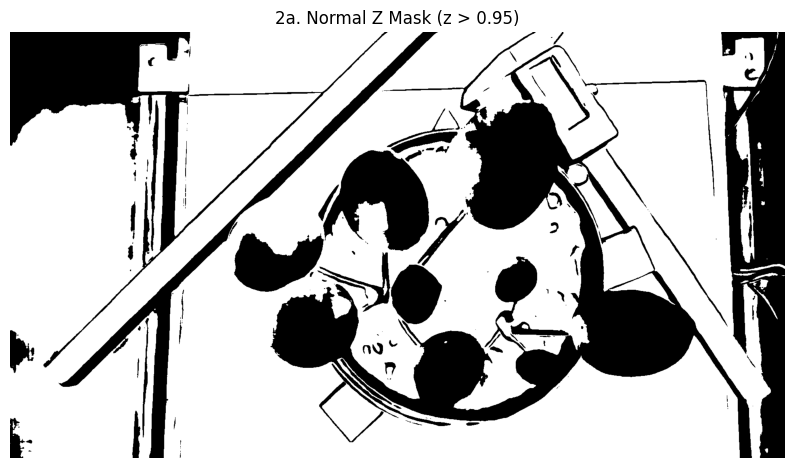

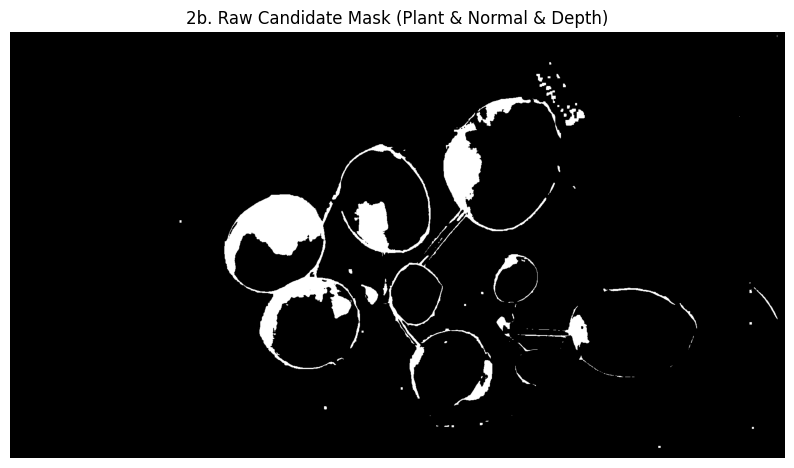

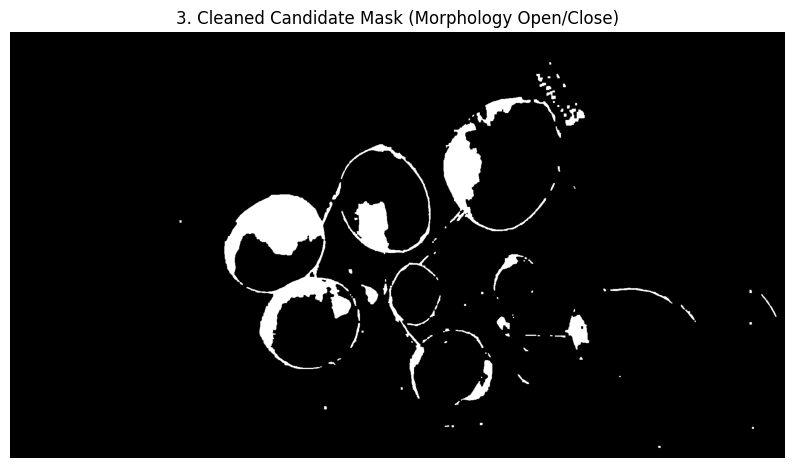

[4. Clustering] 1er DBSCAN (Spatial 3D) sur 88117 points (eps=1.8mm)...
    -> Blobs spatiaux initiaux  : 7
    -> Blobs scindés par normal : 0
    -> Blobs cibles finaux      : 6



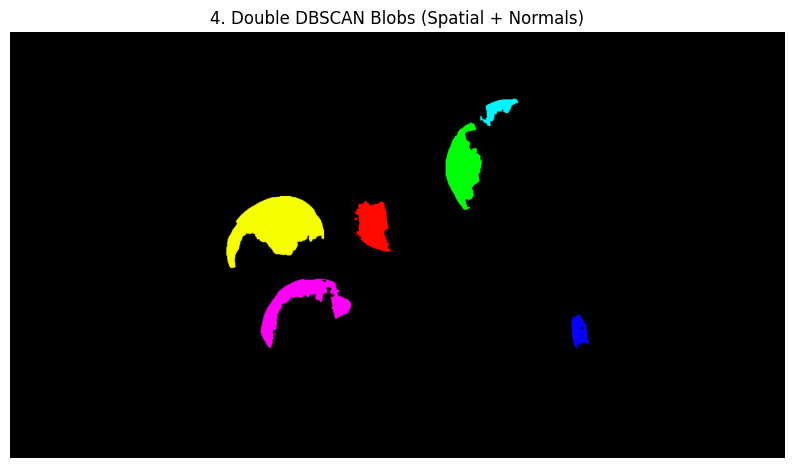

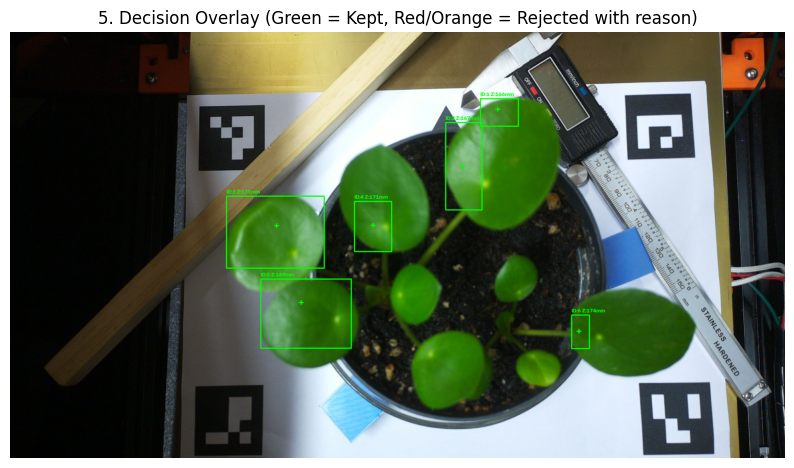


------------------------------ SUMMARY ------------------------------
Total initial blobs: 6
  - Dropped by 'area': 0
  - Dropped by 'extent': 0
  - Dropped by 'border': 0
  - Dropped by 'normal_vector': 0
  - Dropped by 'normal_conf': 0
  - Dropped by 'depth_std': 0
Final valid targets detected: 6



[{'id': 1,
  'pixel': [1208, 193],
  'area_px': 2549,
  'bbox': [1165, 167, 94, 68],
  'normal_confidence': array([[   -0.28495,    -0.29241,    -0.30111, ...,     -0.6934,    -0.68162,     -0.6729],
         [   -0.29109,    -0.29826,    -0.30649, ...,     -0.6975,    -0.68796,    -0.68127],
         [   -0.29856,    -0.30538,    -0.31309, ...,    -0.70392,    -0.69691,    -0.69232],
         ...,
         [   -0.92576,     -0.9242,    -0.92263, ...,    -0.25917,    -0.26719,    -0.27067],
         [   -0.92503,    -0.92348,    -0.92158, ...,    -0.24242,    -0.25049,    -0.25412],
         [   -0.92444,    -0.92295,    -0.92077, ...,    -0.22795,    -0.23632,    -0.24017]], dtype=float32),
  'xyz_mm': [27.475099563598633, -38.58692932128906, 165.66441345214844]},
 {'id': 2,
  'pixel': [1122, 335],
  'area_px': 11651,
  'bbox': [1079, 226, 90, 216],
  'normal_confidence': array([[   -0.28495,    -0.29241,    -0.30111, ...,     -0.6934,    -0.68162,     -0.6729],
         [   -0.29109,

In [47]:

def return_targets():
    print("\n" + "=" * 50)
    print("[DEBUG] START TARGET ESTIMATION PIPELINE")
    print("=" * 50)

# -------------------------------------------------------------
    # 1. Depth Map Scaling & Visualization
    # -------------------------------------------------------------
    tray_depth_values = depth_map[tray_mask > 0]
    if tray_depth_values.size == 0 or np.isclose(np.max(tray_depth_values), 0.0):
        print("[!] Warning: Tray mask is empty or max depth is 0!")
        max_tray_depth = 1.0
    else:
        max_tray_depth = np.max(tray_depth_values)

    tray_z_mm = config["physical"]["tray_z_mm"]
    depth_mm = depth_map * (tray_z_mm / max_tray_depth)
    if plant_height != None:
            depth_mm= (depth_map - np.min(depth_map) )*plant_height/(max_tray_depth-np.min(depth_map)) + (tray_z_mm-plant_height)
    if scale_cube!=None:
            cube_depth = depth_map[cube_mask > 0]
            if cube_depth.size == 0 or np.isclose(np.max(cube_depth), 0.0):
                print("[!] Warning: Cube mask is empty or max depth is 0!")
            else:
                print(
                    f"[+] Cube depth values: {cube_depth.size} pixels, "
                    f"min={np.min(cube_depth) if cube_depth.size > 0 else 0:.2f}, "
                    f"max={np.max(cube_depth):.2f}"
                )
                depth_mm= (depth_map - np.min(cube_depth) )*scale_cube/(max_tray_depth-np.min(cube_depth)) + (tray_z_mm-scale_cube)
    # Remplacement des infinis (et NaNs éventuels) par 400.0 mm
    depth_mm[np.isinf(depth_mm)] = 400.0
    depth_mm[np.isnan(depth_mm)] = 400.0

    print(
        f"[1. Depth Scaling] Min: {np.min(depth_mm):.2f} mm | Max: {np.max(depth_mm):.2f} mm"
    )

    # Visual 1: Scaled Depth Colormap
    depth_vis = cv2.normalize(
        depth_mm, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )
    depth_colormap = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
    show(depth_colormap, "1. Scaled Depth Map (Colormap)")

    # -------------------------------------------------------------
    # 2. Mask Generation & Intermediate Visuals
    # -------------------------------------------------------------
    normal_z = normals[:, :, 2]
    normal_threshold = float(config.get("filtering", {}).get("min_normal_z", 0.94))

    normal_mask = (np.abs(normal_z)> normal_threshold).astype(np.uint8) * 255
    depth_valid_mask = (depth_mm > 0).astype(np.uint8) * 255

    candidate_mask_raw = cv2.bitwise_and(plant_mask, normal_mask)
    candidate_mask_raw = cv2.bitwise_and(candidate_mask_raw, depth_valid_mask)

    # Visual 2: Filtering intermediate masks
    show(normal_mask, f"2a. Normal Z Mask (z > {normal_threshold})")
    show(candidate_mask_raw, "2b. Raw Candidate Mask (Plant & Normal & Depth)")

    # -------------------------------------------------------------
    # 3. Morphology & Cleaning
    # -------------------------------------------------------------
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(candidate_mask_raw, cv2.MORPH_OPEN, kernel)
    candidate_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    show(candidate_mask, "3. Cleaned Candidate Mask (Morphology Open/Close)")

    intrinsics = {
            "fx": float(config["camera"]["fx"]),
            "fy": float(config["camera"]["fy"]),
            "cx": float(config["camera"]["cx"]),
            "cy": float(config["camera"]["cy"]),
            "dist": config["camera"]["dist"],
        }

    # -------------------------------------------------------------
    # 4. Double Clustering DBSCAN (Distance 3D puis Différence Normale Z)
    # -------------------------------------------------------------
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px", 500))
    max_area_px = int(filtering_cfg.get("max_area_px", 12000))
    
    # Paramètres de clustering (ajustables dans config.yaml)
    cluster_eps_mm = float(filtering_cfg.get("cluster_eps_mm", 2.0))       # Tolérance distance 3D (mm)
    cluster_eps_normal = float(filtering_cfg.get("cluster_eps_normal", 0.5)) # Tolérance diff normal_z (ex: 0.05)

    # --- Étape A : Vectorisation du calcul XYZ (Pin-hole model) ---
    h, w = depth_mm.shape
    u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
    
    points_2d = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32).reshape(-1, 1, 2)
    
    K = np.array([
        [intrinsics["fx"], 0, intrinsics["cx"]],
        [0, intrinsics["fy"], intrinsics["cy"]],
        [0, 0, 1]
    ], dtype=np.float32)
    dist_np = np.array(intrinsics["dist"], dtype=np.float32)

    undistorted_pts = cv2.undistortPoints(points_2d, K, dist_np)
    x_norm = undistorted_pts[:, 0, 0].reshape(h, w)
    y_norm = undistorted_pts[:, 0, 1].reshape(h, w)

    X = x_norm * depth_mm
    Y = y_norm * depth_mm
    XYZ_map = np.dstack((X, Y, depth_mm))

    # --- Étape B : Extraction des points candidats ---
    valid_mask = candidate_mask > 0
    valid_XYZ = XYZ_map[valid_mask]
    valid_normals_z = normal_z[valid_mask].reshape(-1, 1) # Format 2D requis pour DBSCAN
    valid_coords = np.column_stack(np.where(valid_mask))  # Format (y, x)

    print(f"[4. Clustering] 1er DBSCAN (Spatial 3D) sur {len(valid_XYZ)} points (eps={cluster_eps_mm}mm)...")
    
    # --- Étape C : Premier DBSCAN (Distance spatiale 3D) ---
    dbscan_spatial = DBSCAN(eps=cluster_eps_mm, min_samples=min_area_px // 4, n_jobs=-1)
    labels_spatial = dbscan_spatial.fit_predict(valid_XYZ)

    # Variables pour stocker les clusters finaux isolés
    final_labels_img = np.zeros((h, w), dtype=np.int32)
    current_label_id = 1
    split_by_normal_count = 0

    unique_spatial_labels = np.unique(labels_spatial)

    # --- Étape D : Deuxième DBSCAN (Orientation normal_z) sur chaque sous-groupe ---
    for sp_lbl in unique_spatial_labels:
        if sp_lbl == -1: 
            continue # Ignorer le bruit
            
        # Index des points appartenant à ce cluster spatial
        idx_cluster = np.where(labels_spatial == sp_lbl)[0]
        
        # S'il y a très peu de points, inutile de relancer un DBSCAN
        if len(idx_cluster) < min_area_px:
            continue
            
        # Récupération des valeurs normal_z du cluster
        cluster_normals = valid_normals_z[idx_cluster]
        
        # Second DBSCAN basé uniquement sur la similarité de l'orientation (normal_z)
        dbscan_norm = DBSCAN(eps=cluster_eps_normal, min_samples=min_area_px // 8, n_jobs=-1)
        labels_norm = dbscan_norm.fit_predict(cluster_normals)
        
        unique_norm_labels = np.unique(labels_norm)
        if len(unique_norm_labels) > 2: # Plus d'un groupe valide détecté (hors bruit -1)
            split_by_normal_count += 1
            
        # --- Étape E : Filtrage final et assignation sur l'image 2D ---
        for n_lbl in unique_norm_labels:
            if n_lbl == -1:
                continue
                
            idx_sub_cluster = idx_cluster[labels_norm == n_lbl]
            area = len(idx_sub_cluster)
            
            if min_area_px <= area <= max_area_px:
                y_c = valid_coords[idx_sub_cluster, 0]
                x_c = valid_coords[idx_sub_cluster, 1]
                final_labels_img[y_c, x_c] = current_label_id
                current_label_id += 1

    # --- Étape F : Construction des stats OpenCV manuellement ---
    # Cette étape remplace cv2.connectedComponentsWithStats pour empêcher
    # la refusion de 2 feuilles qui se touchent en 2D mais ont été séparées par DBSCAN.
    num_labels = current_label_id
    labels = final_labels_img
    stats = np.zeros((num_labels, 5), dtype=np.int32)
    centroids = np.zeros((num_labels, 2), dtype=np.float64)

    for i in range(1, num_labels):
        y_idx, x_idx = np.where(labels == i)
        stats[i, cv2.CC_STAT_LEFT] = x_idx.min()
        stats[i, cv2.CC_STAT_TOP] = y_idx.min()
        stats[i, cv2.CC_STAT_WIDTH] = x_idx.max() - x_idx.min() + 1
        stats[i, cv2.CC_STAT_HEIGHT] = y_idx.max() - y_idx.min() + 1
        stats[i, cv2.CC_STAT_AREA] = len(x_idx)
        centroids[i, 0] = x_idx.mean()
        centroids[i, 1] = y_idx.mean()

    total_blobs = num_labels - 1
    
    print(f"    -> Blobs spatiaux initiaux  : {len(unique_spatial_labels) - 1}")
    print(f"    -> Blobs scindés par normal : {split_by_normal_count}")
    print(f"    -> Blobs cibles finaux      : {total_blobs}\n")

    # Visual 4: Colored DBSCAN Blobs
    if num_labels > 1:
        label_hue = np.uint8(179 * labels / np.max(labels))
        blank_ch = 255 * np.ones_like(label_hue)
        labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
        labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
        labeled_img[labels == 0] = 0
        show(labeled_img, "4. Double DBSCAN Blobs (Spatial + Normals)")
    # -------------------------------------------------------------
    # 5. Filtering Criteria & Debug Overlay
    # -------------------------------------------------------------
    intrinsics = {
        "fx": float(config["camera"]["fx"]),
        "fy": float(config["camera"]["fy"]),
        "cx": float(config["camera"]["cx"]),
        "cy": float(config["camera"]["cy"]),
        "dist": config["camera"]["dist"],
    }
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px",500))

    targets = []
    rejection_stats = {
        "area": 0,
        "extent": 0,
        "border": 0,
        "normal_vector": 0,
        "normal_conf": 0,
        "depth_std": 0,
    }

    # Prepare visual overlay (RGB copy)
    debug_overlay = image.copy()
    if len(debug_overlay.shape) == 2 or debug_overlay.shape[2] == 1:
        debug_overlay = cv2.cvtColor(debug_overlay, cv2.COLOR_GRAY2BGR)

    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        left = int(stats[label_idx, cv2.CC_STAT_LEFT])
        top = int(stats[label_idx, cv2.CC_STAT_TOP])
        width = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        height = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        cx, cy = centroids[label_idx]
        u, v = int(round(cx)), int(round(cy))

        # Check 1: Area
        if area < min_area_px:
            print(f"blob with area {area} rejected because less than {min_area_px}")
            rejection_stats["area"] += 1
            cv2.rectangle(
                debug_overlay,
                (left, top),
                (left + width, top + height),
                (0, 0, 255),
                1,
            )
            cv2.putText(
                debug_overlay,
                f"#{label_idx}: Area",
                (left, max(15, top - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 255),
                1,
            )
            continue
        xyz = depth_to_camera_xyz(depth_mm, u, v, intrinsics)
       

        # ACCEPTED TARGET -> Green bounding box and centroid marker
        cv2.rectangle(
            debug_overlay,
            (left, top),
            (left + width, top + height),
            (0, 255, 0),
            2,
        )
        cv2.drawMarker(
            debug_overlay,
            (u, v),
            (0, 255, 0),
            markerType=cv2.MARKER_CROSS,
            markerSize=10,
            thickness=2,
        )
        cv2.putText(
            debug_overlay,
            f"ID:{label_idx} Z:{xyz[2]:.0f}mm",
            (left, max(18, top - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            2,
        )

        targets.append(
            {
                "id": label_idx,
                "pixel": [int(u), int(v)],
                "area_px": area,
                "bbox": [left, top, width, height],
                "normal_confidence": normal_z,
                "xyz_mm": [float(xyz[0]), float(xyz[1]), float(xyz[2])],
            }
        )

    # Visual 5: Final diagnostic overlay
    show(
        debug_overlay,
        "5. Decision Overlay (Green = Kept, Red/Orange = Rejected with reason)",
    )

    print("\n" + "-" * 30 + " SUMMARY " + "-" * 30)
    print(f"Total initial blobs: {total_blobs}")
    for reason, count in rejection_stats.items():
        print(f"  - Dropped by '{reason}': {count}")
    print(f"Final valid targets detected: {len(targets)}")
    print("=" * 69 + "\n")

    return targets
return_targets()

Test avec le clustering de feuillles avant les dbscan



[DEBUG] START TARGET ESTIMATION PIPELINE
[1. Depth Scaling] Min: 160.00 mm | Max: 320.41 mm


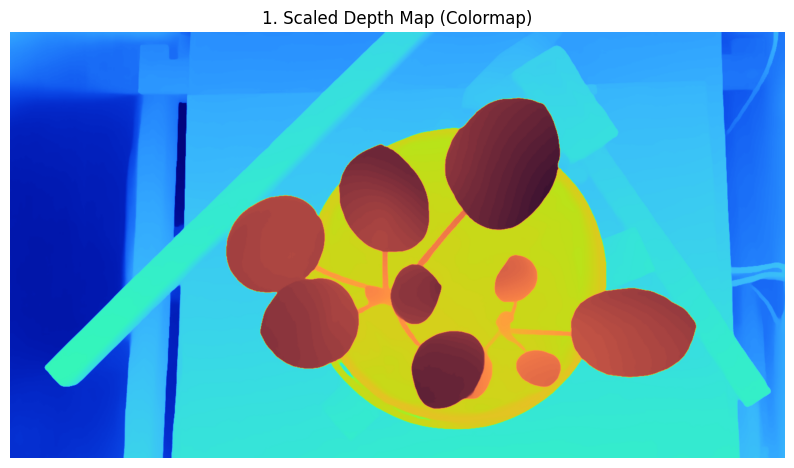

[3. Plant Clustering] Génération du nuage de points global...
[+] 35 plantes uniques isolées.
    -> Plantes segmentées       : 35
    -> Blobs scindés par normal : 0
    -> Feuilles isolées finales : 5



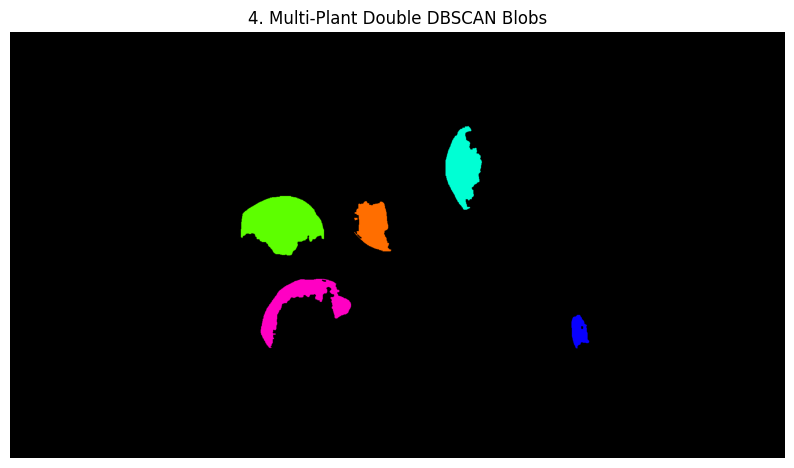

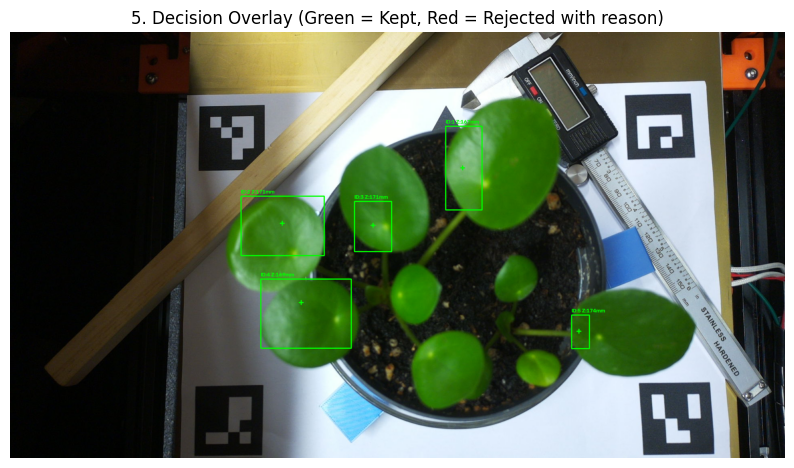


------------------------------ SUMMARY ------------------------------
Total initial blobs: 5
  - Dropped by 'area': 0
Final valid targets detected: 5



[{'id': 1,
  'pixel': [1121, 338],
  'area_px': 11345,
  'bbox': [1079, 235, 90, 207],
  'normal_confidence': -0.9717897772789001,
  'normal_std': 0.010363652370870113,
  'xyz_mm': [17.6872615814209, -22.316606521606445, 166.5523223876953]},
 {'id': 2,
  'pixel': [674, 475],
  'area_px': 20312,
  'bbox': [572, 408, 206, 147],
  'normal_confidence': -0.9785403609275818,
  'normal_std': 0.013188167475163937,
  'xyz_mm': [-34.50798034667969, -6.90902853012085, 171.21148681640625]},
 {'id': 3,
  'pixel': [899, 480],
  'area_px': 7625,
  'bbox': [853, 421, 92, 124],
  'normal_confidence': -0.963883638381958,
  'normal_std': 0.011652927845716476,
  'xyz_mm': [-7.938207626342773, -6.297080993652344, 170.57762145996094]},
 {'id': 4,
  'pixel': [721, 671],
  'area_px': 11144,
  'bbox': [621, 613, 224, 171],
  'normal_confidence': -0.9349613785743713,
  'normal_std': 0.01240236684679985,
  'xyz_mm': [-28.510408401489258, 15.799602508544922, 168.5260772705078]},
 {'id': 5,
  'pixel': [1409, 742],

In [48]:
import cv2
import numpy as np
import open3d as o3d
from sklearn.cluster import DBSCAN

def run_extract_leaf_clusters(
    pcd,
    distance_threshold,
    min_points,
    size_threshold,
    shape_threshold,
    height_ratio,
):
    downsampled = pcd.voxel_down_sample(voxel_size=0.005)
    labels = np.asarray(
        downsampled.cluster_dbscan(
            eps=distance_threshold, min_points=min_points, print_progress=False
        )
    )
    if labels.size == 0:
        return []
    points = np.asarray(downsampled.points)
    z_min = points[:, 2].min()
    total_height = points[:, 2].max() - z_min
    clusters = []
    for label in range(labels.max() + 1):
        cluster_points = points[labels == label]
        if len(cluster_points) < 3:
            continue
        eigenvalues = np.linalg.eigvalsh(np.cov(cluster_points.T))
        eval_sum = eigenvalues.sum()
        centroid = cluster_points.mean(axis=0)
        if (
            eigenvalues[-1] > size_threshold
            and eval_sum > 0
            and eigenvalues[-1] / eval_sum < shape_threshold
            and centroid[2] - z_min > total_height * height_ratio
        ):
            cluster = o3d.geometry.PointCloud()
            cluster.points = o3d.utility.Vector3dVector(cluster_points)
            clusters.append(cluster)
    return clusters

def return_targets():
    print("\n" + "=" * 50)
    print("[DEBUG] START TARGET ESTIMATION PIPELINE")
    print("=" * 50)

    tray_depth_values = depth_map[tray_mask > 0]
    if tray_depth_values.size == 0 or np.isclose(np.max(tray_depth_values), 0.0):
        print("[!] Warning: Tray mask is empty or max depth is 0!")
        max_tray_depth = 1.0
    else:
        max_tray_depth = np.max(tray_depth_values)

    tray_z_mm = config["physical"]["tray_z_mm"]
    depth_mm = depth_map * (tray_z_mm / max_tray_depth)
    if plant_height != None:
        depth_mm = (depth_map - np.min(depth_map)) * plant_height / (max_tray_depth - np.min(depth_map)) + (tray_z_mm - plant_height)
    if scale_cube != None:
        cube_depth = depth_map[cube_mask > 0]
        if cube_depth.size == 0 or np.isclose(np.max(cube_depth), 0.0):
            print("[!] Warning: Cube mask is empty or max depth is 0!")
        else:
            depth_mm = (depth_map - np.min(cube_depth)) * scale_cube / (max_tray_depth - np.min(cube_depth)) + (tray_z_mm - scale_cube)
    depth_mm[np.isinf(depth_mm)] = 400.0
    depth_mm[np.isnan(depth_mm)] = 400.0

    print(f"[1. Depth Scaling] Min: {np.min(depth_mm):.2f} mm | Max: {np.max(depth_mm):.2f} mm")
    depth_vis = cv2.normalize(depth_mm, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    depth_colormap = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
    show(depth_colormap, "1. Scaled Depth Map (Colormap)")

    intrinsics = {
        "fx": float(config["camera"]["fx"]),
        "fy": float(config["camera"]["fy"]),
        "cx": float(config["camera"]["cx"]),
        "cy": float(config["camera"]["cy"]),
        "dist": config["camera"]["dist"],
    }
    h, w = depth_mm.shape
    u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
    points_2d = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32).reshape(-1, 1, 2)
    K = np.array([
        [intrinsics["fx"], 0, intrinsics["cx"]],
        [0, intrinsics["fy"], intrinsics["cy"]],
        [0, 0, 1]
    ], dtype=np.float32)
    dist_np = np.array(intrinsics["dist"], dtype=np.float32)
    undistorted_pts = cv2.undistortPoints(points_2d, K, dist_np)
    x_norm = undistorted_pts[:, 0, 0].reshape(h, w)
    y_norm = undistorted_pts[:, 0, 1].reshape(h, w)
    X = x_norm * depth_mm
    Y = y_norm * depth_mm
    XYZ_map = np.dstack((X, Y, depth_mm)) / 1000.0

    print("[3. Plant Clustering] Génération du nuage de points global...")
    valid_depth_mask = depth_mm > 0
    global_pcd = o3d.geometry.PointCloud()
    global_pcd.points = o3d.utility.Vector3dVector(XYZ_map[valid_depth_mask])
    plant_clusters = run_extract_leaf_clusters(
        global_pcd,
        distance_threshold=0.0092,
        min_points=20,
        size_threshold=1e-5,
        shape_threshold=0.98,
        height_ratio=0.1
    )
    print(f"[+] {len(plant_clusters)} plantes uniques isolées.")

    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px", 500))
    max_area_px = int(filtering_cfg.get("max_area_px", 12000))
    cluster_eps_mm = float(filtering_cfg.get("cluster_eps_mm", 2.0))
    cluster_eps_normal = float(filtering_cfg.get("cluster_eps_normal", 0.5))
    normal_threshold = float(filtering_cfg.get("min_normal_z", 0.94))
    normal_z = normals[:, :, 2]
    base_normal_mask = (np.abs(normal_z) > normal_threshold).astype(np.uint8) * 255
    final_labels_img = np.zeros((h, w), dtype=np.int32)
    weighted_centroids = {}
    current_label_id = 1
    total_split_by_normal = 0

    for plant_pcd in plant_clusters:
        bbox = plant_pcd.get_axis_aligned_bounding_box()
        min_b = bbox.get_min_bound() - 0.015
        max_b = bbox.get_max_bound() + 0.015
        plant_spatial_mask = (
            (XYZ_map[..., 0] >= min_b[0]) & (XYZ_map[..., 0] <= max_b[0]) &
            (XYZ_map[..., 1] >= min_b[1]) & (XYZ_map[..., 1] <= max_b[1]) &
            (XYZ_map[..., 2] >= min_b[2]) & (XYZ_map[..., 2] <= max_b[2])
        )
        candidate_mask_raw = cv2.bitwise_and(plant_mask, base_normal_mask)
        candidate_mask_raw = cv2.bitwise_and(candidate_mask_raw, plant_spatial_mask.astype(np.uint8) * 255)
        kernel = np.ones((3, 3), np.uint8)
        opened = cv2.morphologyEx(candidate_mask_raw, cv2.MORPH_OPEN, kernel)
        candidate_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
        valid_mask = candidate_mask > 0
        valid_XYZ = XYZ_map[valid_mask]
        valid_normals_z = normal_z[valid_mask].reshape(-1, 1)
        valid_coords = np.column_stack(np.where(valid_mask))
        if len(valid_XYZ) < min_area_px:
            continue

        dbscan_spatial = DBSCAN(eps=cluster_eps_mm / 1000.0, min_samples=max(1, min_area_px // 4), n_jobs=1)
        labels_spatial = dbscan_spatial.fit_predict(valid_XYZ)
        for sp_lbl in np.unique(labels_spatial):
            if sp_lbl == -1:
                continue
            idx_cluster = np.where(labels_spatial == sp_lbl)[0]
            if len(idx_cluster) < min_area_px:
                continue

            cluster_normals = valid_normals_z[idx_cluster]
            dbscan_norm = DBSCAN(eps=cluster_eps_normal, min_samples=max(1, min_area_px // 8), n_jobs=1)
            labels_norm = dbscan_norm.fit_predict(cluster_normals)
            subclusters = []
            for n_lbl in np.unique(labels_norm):
                if n_lbl == -1:
                    continue
                idx_sub_cluster = idx_cluster[labels_norm == n_lbl]
                area = len(idx_sub_cluster)
                if min_area_px <= area <= max_area_px:
                    normal_values = normal_z[valid_coords[idx_sub_cluster, 0], valid_coords[idx_sub_cluster, 1]]
                    subclusters.append((float(np.std(normal_values)), idx_sub_cluster))

            if not subclusters:
                continue
            if len(subclusters) > 1:
                total_split_by_normal += 1

            _, selected_idx = min(subclusters, key=lambda item: item[0]) #Choisir le sous-cluster avec la plus petite variance de normal_z
            y_selected = valid_coords[selected_idx, 0]
            x_selected = valid_coords[selected_idx, 1]
            final_labels_img[y_selected, x_selected] = current_label_id
            weights = np.abs(normal_z[y_selected, x_selected]).astype(np.float64)
            weight_sum = weights.sum()
            if weight_sum <= 0:
                weights = np.ones_like(weights)
                weight_sum = weights.sum()
            weighted_centroids[current_label_id] = (
                float(np.average(x_selected, weights=weights)),
                float(np.average(y_selected, weights=weights)),
            )
            current_label_id += 1

    num_labels = current_label_id
    labels = final_labels_img
    stats = np.zeros((num_labels, 5), dtype=np.int32)
    centroids = np.zeros((num_labels, 2), dtype=np.float64)
    nonempty_labels = 0
    for i in range(1, num_labels):
        y_idx, x_idx = np.where(labels == i)
        if x_idx.size == 0:
            continue
        nonempty_labels += 1
        stats[i, cv2.CC_STAT_LEFT] = x_idx.min()
        stats[i, cv2.CC_STAT_TOP] = y_idx.min()
        stats[i, cv2.CC_STAT_WIDTH] = x_idx.max() - x_idx.min() + 1
        stats[i, cv2.CC_STAT_HEIGHT] = y_idx.max() - y_idx.min() + 1
        stats[i, cv2.CC_STAT_AREA] = len(x_idx)
        centroids[i] = weighted_centroids.get(i, (x_idx.mean(), y_idx.mean()))

    total_blobs = nonempty_labels
    print(f"    -> Plantes segmentées       : {len(plant_clusters)}")
    print(f"    -> Blobs scindés par normal : {total_split_by_normal}")
    print(f"    -> Feuilles isolées finales : {total_blobs}\n")

    if np.any(labels > 0):
        label_hue = np.uint8(179 * labels / np.max(labels))
        blank_ch = 255 * np.ones_like(label_hue)
        labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
        labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
        labeled_img[labels == 0] = 0
        show(labeled_img, "4. Multi-Plant Double DBSCAN Blobs")

    targets = []
    rejection_stats = {"area": 0}
    debug_overlay = image.copy()
    if len(debug_overlay.shape) == 2 or debug_overlay.shape[2] == 1:
        debug_overlay = cv2.cvtColor(debug_overlay, cv2.COLOR_GRAY2BGR)
    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        if area == 0:
            continue
        left = int(stats[label_idx, cv2.CC_STAT_LEFT])
        top = int(stats[label_idx, cv2.CC_STAT_TOP])
        width = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        height = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        cx, cy = centroids[label_idx]
        u, v = int(round(cx)), int(round(cy))
        if area < min_area_px:
            rejection_stats["area"] += 1
            cv2.rectangle(debug_overlay, (left, top), (left + width, top + height), (0, 0, 255), 1)
            cv2.putText(debug_overlay, f"#{label_idx}: Area", (left, max(15, top - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
            continue
        xyz = depth_to_camera_xyz(depth_mm, u, v, intrinsics)
        cv2.rectangle(debug_overlay, (left, top), (left + width, top + height), (0, 255, 0), 2)
        cv2.drawMarker(debug_overlay, (u, v), (0, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.putText(debug_overlay, f"ID:{label_idx} Z:{xyz[2]:.0f}mm", (left, max(18, top - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 2)
        targets.append({
            "id": label_idx,
            "pixel": [int(u), int(v)],
            "area_px": area,
            "bbox": [left, top, width, height],
            "normal_confidence": float(normal_z[v, u]),
            "normal_std": float(np.std(normal_z[labels == label_idx])),
            "xyz_mm": [float(xyz[0]), float(xyz[1]), float(xyz[2])],
        })

    show(debug_overlay, "5. Decision Overlay (Green = Kept, Red = Rejected with reason)")
    print("\n" + "-" * 30 + " SUMMARY " + "-" * 30)
    print(f"Total initial blobs: {total_blobs}")
    for reason, count in rejection_stats.items():
        print(f"  - Dropped by '{reason}': {count}")
    print(f"Final valid targets detected: {len(targets)}")
    print("=" * 69 + "\n")
    return targets

return_targets()